In [32]:
# This cell ought** to contain everything necessary for the following code to run. - Andy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from scipy.optimize import minimize_scalar


%matplotlib inline
np.set_printoptions(precision=4, suppress=True)
SEED = 6740

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Data Preparation

In [33]:
returns_full = pd.read_parquet("data_raw/sp500_returns_matrix.parquet")
returns_full.index = pd.to_datetime(returns_full.index)
returns_full = returns_full.sort_index()

constituent_history = pd.read_parquet("data_raw/sp500_constituent_history.parquet")
constituent_history["date"] = pd.to_datetime(constituent_history["date"])
constituent_history = constituent_history.sort_values("date").reset_index(drop=True)

permno_ticker_map = pd.read_parquet("data_raw/permno_ticker_map.parquet")

print(f"returns_full:        {returns_full.shape}, {returns_full.index.min().date()} \u2192 {returns_full.index.max().date()}")
print(f"constituent_history: {constituent_history.shape}, {len(constituent_history)} membership snapshots")
print(f"permno_ticker_map:   {permno_ticker_map.shape}")

returns_full:        (6289, 1322), 2000-01-03 → 2024-12-31
constituent_history: (2213, 2), 2213 membership snapshots
permno_ticker_map:   (5456, 5)


In [34]:
def members_as_of(date, history=constituent_history):
    """
    Purpose: Pulls the tickers S&P members 'as of' a given date (binary search on snapshot dates). This prevents survivorship bias since the S&P prunes the 'losers.'
    
    Inputs: Date and constituency 

    Outputs: A list of stock tickers
    """
    target = pd.to_datetime(date)
    idx = history["date"].searchsorted(target, side="right") - 1
    if idx < 0:
        raise ValueError(f"No constituent record on or before {date}")
    return set(history.iloc[idx]["tickers"].split(","))


# Returns_full column -> base ticker (strip the _PERMNO suffix used only when CRSP reused a ticker across companies). Cached as a Series.
_base_ticker = pd.Series(
    [c.split("_")[0] for c in returns_full.columns],
    index=returns_full.columns,
)


def members_to_columns(member_tickers):
    """
    Purpose: Builds a dataframe with the returns (over a predetermined window) of the companies in the member_tickers list.
    
    Inputs: A list of tickers

    Outputs: returns_full columns whose base ticker is in the membership set.
    """
    return returns_full.columns[_base_ticker.isin(member_tickers)]


# Lambda function: Maps column label to (ticker, company name) using the permno_ticker_map
_pt_latest = permno_ticker_map.sort_values("namedt").groupby("permno", as_index=False).last()[["permno", "ticker", "comnam"]]
_ticker_freq = Counter(_pt_latest["ticker"])
_pt_latest["col_label"] = _pt_latest.apply(
    lambda r: f"{r['ticker']}_{r['permno']}" if _ticker_freq[r["ticker"]] > 1 else r["ticker"],
    axis=1,
)
col_to_company = dict(zip(_pt_latest["col_label"], _pt_latest["comnam"]))

print("Testing Data Processing:")
print(f"  Example \u2014 members_as_of('2019-12-31'):  {len(members_as_of('2019-12-31'))} tickers")
print(f"  Example \u2014 col_to_company['ORCL']:       {col_to_company.get('ORCL')}")
print(f"  Example \u2014 col_to_company['JAVA_10078']: {col_to_company.get('JAVA_10078')}")

print(f"returns_full:        {returns_full.shape}, {returns_full.index.min().date()} → {returns_full.index.max().date()}")
print(f"constituent_history: {constituent_history.shape}")
print(f"permno_ticker_map:   {permno_ticker_map.shape}")

Testing Data Processing:
  Example — members_as_of('2019-12-31'):  505 tickers
  Example — col_to_company['ORCL']:       ORACLE CORP
  Example — col_to_company['JAVA_10078']: SUN MICROSYSTEMS INC
returns_full:        (6289, 1322), 2000-01-03 → 2024-12-31
constituent_history: (2213, 2)
permno_ticker_map:   (5456, 5)


In [35]:
# Single-window analysis. 2-year pre-COVID baseline, which keeps q = p/n < 1 and avoids the 2020 vol spike from contaminating the noise-bulk estimate.
AS_OF_DATE = "2019-12-31"
WINDOW_START = "2018-01-01"
WINDOW_END = "2019-12-31"

# Real S&P 500 membership at the as-of date
members = members_as_of(AS_OF_DATE)
member_cols = members_to_columns(members)

# Slice to window and member columns
returns_win = returns_full.loc[WINDOW_START:WINDOW_END, member_cols]

# Drop assets with any missing return in the window (no imputation)
returns_win = returns_win.dropna(axis=1, how="any")

# Cast from pandas nullable Float64 to NumPy float64 for downstream math
X_raw = returns_win.to_numpy(dtype=float)
n, p = X_raw.shape
q = p / n

print(f"As-of date:                {AS_OF_DATE}")
print(f"S&P members at as-of:      {len(members)}")
print(f"Members with any data:     {len(member_cols)}")
print(f"Members with full window:  {p}")
print(f"Window:                    {WINDOW_START} → {WINDOW_END}")
print(f"  n (days):                {n}")
print(f"  p (assets):              {p}")
print(f"  q = p/n:                 {q:.3f}")

As-of date:                2019-12-31
S&P members at as-of:      505
Members with any data:     589
Members with full window:  489
Window:                    2018-01-01 → 2019-12-31
  n (days):                503
  p (assets):              489
  q = p/n:                 0.972


In [36]:
# Demean (column-wise) and build covariance via X.T @ X 
X = X_raw - X_raw.mean(axis=0, keepdims=True)
cov = (X.T @ X) / (n - 1)

# Eigendecomposition. eigh returns ascending evals, so we need to flip the indexing to descending.
evals, evecs = eigh(cov)
evals = evals[::-1]
evecs = evecs[:, ::-1]

print(f"Covariance shape:     {cov.shape}")
print(f"Top 5 eigenvalues:    {evals[:5]}")
print(f"Total variance (\u03a3\u03bb): {evals.sum():.6e}")
print(f"Top eig share:        {evals[0] / evals.sum():.1%}")

Covariance shape:     (489, 489)
Top 5 eigenvalues:    [0.0461 0.0068 0.0046 0.0039 0.0035]
Total variance (Σλ): 1.529194e-01
Top eig share:        30.1%


# Method 1 - Marchenko-Pastur (RMT)

In [37]:
def mp_density(lam, sigma2_, q_):
    """
    Purpose: Marchenko-Pastur continuous density at points `lam`.
    
    Inputs: Eigenvalue, noise estimate, q_ = p/n

    Outputs: Marchenko-Pastur Density
    """
    
    lam_p = sigma2_ * (1 + np.sqrt(q_)) ** 2
    lam_m = sigma2_ * (1 - np.sqrt(q_)) ** 2
    out = np.zeros_like(lam, dtype=float)
    inside = (lam > lam_m) & (lam < lam_p)
    out[inside] = np.sqrt((lam_p - lam[inside]) * (lam[inside] - lam_m)) / (2 * np.pi * sigma2_ * q_ * lam[inside])
    return out


def iter_sigma2(evals_, q_, max_iter=100, tol=1e-12):
    """
    Purpose: Iteratively trim eigenvalues above the implied MP edge; σ² is the mean of what remains

    Filters to strictly positive eigenvalues so rank-deficiency artifacts (when the
    sample cov is rank < p — happens with q > 1 OR with bootstrap-resampled data
    that has duplicate rows) don't drag σ² toward zero and inflate the signal count.
    
    Inputs: Eigenvalues, q_ = p/n, max_iterations, convergence criteria

    Outputs: Noise estimate, σ²
    """
    positive = evals_[evals_ > 1e-14 * max(evals_.max(), 1e-30)]
    if len(positive) == 0:
        return float(max(evals_.max(), 1e-30))
    sigma2_ = positive.mean()
    for _ in range(max_iter):
        edge = sigma2_ * (1 + np.sqrt(q_)) ** 2
        keep = positive <= edge
        if keep.sum() == 0:
            break
        new_sigma2 = positive[keep].mean()
        if abs(new_sigma2 - sigma2_) < tol * sigma2_:
            sigma2_ = new_sigma2
            break
        sigma2_ = new_sigma2
    return sigma2_


def fit_sigma2(evals_, q_, bulk_quantile=0.9, n_bins=50):
    """
    Purpose: Choose σ² to minimize L² distance between empirical bulk histogram and MP density.

    Filters to strictly positive eigenvalues so rank-deficiency artifacts (when the
    sample cov is rank < p — happens with q > 1 OR with bootstrap-resampled data
    that has duplicate rows) don't drag σ² toward zero and inflate the signal count.
    
    Inputs: Eigenvalues, q_ = p/n, quantile, number of histogram bins

    Outputs: Noise estimate, σ²
    """
    cutoff = np.quantile(evals_, bulk_quantile)
    bulk = evals_[evals_ <= cutoff]
    hist, edges = np.histogram(bulk, bins=n_bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])
    s0 = evals_.mean()
    res = minimize_scalar(
        lambda s2: np.sum((hist - mp_density(centers, s2, q_)) ** 2),
        bounds=(s0 * 0.05, s0 * 5),
        method="bounded",
    )
    return res.x


def rmt_count(s2, evs, q_):
    return int((evs > s2 * (1 + np.sqrt(q_)) ** 2).sum())


# Compare the three σ² estimators on the single-window spectrum
sigma2_median = np.median(evals[p // 2 :]) # median of the lower half method
sigma2_iter = iter_sigma2(evals, q)
sigma2_fit = fit_sigma2(evals, q)

print(f"{'method':<22}  {'σ²':>14}  {'λ+':>14}  {'#signal':>8}")
for name, s2 in [
    ("bottom-half median", sigma2_median),
    ("iterative trim", sigma2_iter),
    ("MP density fit", sigma2_fit),
]:
    edge = s2 * (1 + np.sqrt(q)) ** 2
    print(f"{name:<22}  {s2:>14.4e}  {edge:>14.4e}  {rmt_count(s2, evals, q):>8d}")

# Iterative trim will be the standard approach going forward, or as my teammates (probably just John) like to say "canonical."
sigma2 = sigma2_iter
mp_upper = sigma2 * (1 + np.sqrt(q)) ** 2
mp_lower = sigma2 * (1 - np.sqrt(q)) ** 2 if q < 1 else 0.0
rmt_dim = rmt_count(sigma2, evals, q)
print(f"\nCanonical RMT dimension (iterative): {rmt_dim}")
print(f"Top {min(rmt_dim, 10)} signal eigenvalues: {evals[:min(rmt_dim, 10)]}")

method                              σ²              λ+   #signal
bottom-half median          1.1042e-05      4.3553e-05       270
iterative trim              4.1321e-05      1.6298e-04       149
MP density fit              4.0122e-05      1.5825e-04       152

Canonical RMT dimension (iterative): 149
Top 10 signal eigenvalues: [0.0461 0.0068 0.0046 0.0039 0.0035 0.0027 0.0024 0.0019 0.0017 0.0016]


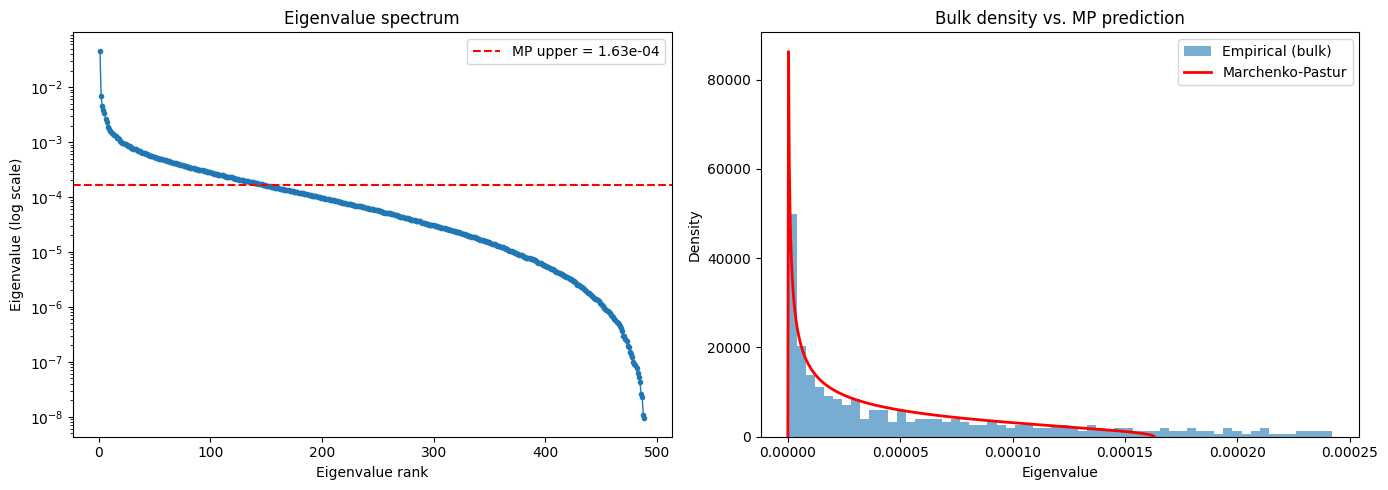

In [38]:
"""
tl;dr if you are above the red lines in either plot, you aren't what MP says you should be, and therefore, statistically significant.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Left: full spectrum (log scale) with MP threshold
axes[0].plot(np.arange(1, len(evals) + 1), evals, marker=".", linestyle="-", linewidth=1)
axes[0].axhline(mp_upper, color="red", linestyle="--", label=f"MP upper = {mp_upper:.2e}")
axes[0].set_xlabel("Eigenvalue rank")
axes[0].set_ylabel("Eigenvalue (log scale)")
axes[0].set_yscale("log")
axes[0].set_title("Eigenvalue spectrum")
axes[0].legend()

# Right: empirical density of the bulk vs. theoretical MP density
bulk = evals[evals < mp_upper * 1.5]
axes[1].hist(bulk, bins=60, density=True, alpha=0.6, label="Empirical (bulk)")

lam = np.linspace(max(mp_lower, 1e-12), mp_upper, 500)
mp_density = np.sqrt(np.maximum((mp_upper - lam) * (lam - mp_lower), 0)) / (2 * np.pi * sigma2 * q * lam)
axes[1].plot(lam, mp_density, color="red", linewidth=2, label="Marchenko-Pastur")
axes[1].set_xlabel("Eigenvalue")
axes[1].set_ylabel("Density")
axes[1].set_title("Bulk density vs. MP prediction")
axes[1].legend()

plt.tight_layout()
plt.show()

# Method 2 - Participation Ratio (PR)

In [39]:
# This will be functionalized later
pr_dim = (evals.sum() ** 2) / (evals**2).sum()
print(f"Participation ratio dimension:  {pr_dim:.2f}")
print(f"  (variance spread is equivalent to ~{pr_dim:.0f} equally-weighted modes)")

Participation ratio dimension:  10.24
  (variance spread is equivalent to ~10 equally-weighted modes)


# Method 3 - Levina-Bickel (LB)

In [40]:
# This will be functionalized later
K = 10  # neighbor count

nbrs = NearestNeighbors(n_neighbors=K + 1).fit(X)
distances, _ = nbrs.kneighbors(X)
# distances[:, 0] is the self-distance (= 0); distances[:, 1:K+1] are the K nearest neighbors

T_k = distances[:, K]  # shape (n,) - distance to k-th NN
T_j = distances[:, 1:K]  # shape (n, K-1) - distances to NN 1..K-1

eps = 1e-12  # guard against zero distances
log_ratios = np.log((T_k[:, None] + eps) / (T_j + eps))
local_dims = (K - 1) / log_ratios.sum(axis=1)
local_dims = local_dims[np.isfinite(local_dims)]

lb_dim = local_dims.mean()

print(f"Levina-Bickel dimension (k={K}):  {lb_dim:.2f}")
print(f"  Averaged over {len(local_dims)} valid sample points")

Levina-Bickel dimension (k=10):  29.48
  Averaged over 503 valid sample points


# Dimensionality Estimate Comparisons

In [41]:
summary = pd.DataFrame(
    {
        "estimator": ["RMT (MP upper edge)", "Participation Ratio", "Levina-Bickel"],
        "dimension": [rmt_dim, round(pr_dim, 2), round(lb_dim, 2)],
        "type": ["integer / linear", "continuous / linear", "continuous / nonlinear"],
    }
)
print(f"Window: {WINDOW_START} to {WINDOW_END}  (n={n}, p={p}, q={q:.3f})\n")
print(summary.to_string(index=False))

Window: 2018-01-01 to 2019-12-31  (n=503, p=489, q=0.972)

          estimator  dimension                   type
RMT (MP upper edge)   149.0000       integer / linear
Participation Ratio    10.2400    continuous / linear
      Levina-Bickel    29.4800 continuous / nonlinear


In [42]:
pc1 = evecs[:, 0]
pc1_df = pd.DataFrame(
    {
        "ticker": returns_win.columns,
        "company": [col_to_company.get(c, "?") for c in returns_win.columns],
        "weight": pc1,
    }
)
pc1_df["abs_weight"] = pc1_df["weight"].abs()

print("Top 10 PC1 loadings by absolute weight:")
print(pc1_df.sort_values("abs_weight", ascending=False).head(10).to_string(index=False))
print()
print(f"PC1 sign distribution:  {(pc1 > 0).sum()} positive, {(pc1 < 0).sum()} negative")
print(f"  (mostly same-sign \u2192 broad market mode; mixed \u2192 sector or style factor)")

Top 10 PC1 loadings by absolute weight:
   ticker                    company  weight  abs_weight
      AMD ADVANCED MICRO DEVICES INC -0.0953      0.0953
     NVDA                NVIDIA CORP -0.0919      0.0919
      URI         UNITED RENTALS INC -0.0893      0.0893
       MU      MICRON TECHNOLOGY INC -0.0887      0.0887
     IPGP       I P G PHOTONICS CORP -0.0816      0.0816
      WDC       WESTERN DIGITAL CORP -0.0775      0.0775
FCX_81774       FREEPORT MCMORAN INC -0.0763      0.0763
     LRCX              LAM RESH CORP -0.0751      0.0751
     SIVB      S V B FINANCIAL GROUP -0.0749      0.0749
     AMAT      APPLIED MATERIALS INC -0.0743      0.0743

PC1 sign distribution:  0 positive, 489 negative
  (mostly same-sign → broad market mode; mixed → sector or style factor)


In [43]:
WIN_DAYS = 252  # 1 trading year
STEP_DAYS = 63  # Roughly 1 trading quarter
K_ROLL = 10

dates = returns_full.index
records = []

for start_idx in range(0, len(dates) - WIN_DAYS + 1, STEP_DAYS):
    end_idx = start_idx + WIN_DAYS
    end_date = dates[end_idx - 1]

    # Per-window membership: S&P constituents at the window's end date
    members_w = members_as_of(end_date)
    cols_w = members_to_columns(members_w)

    win = returns_full.iloc[start_idx:end_idx][cols_w].dropna(axis=1, how="any")
    n_w, p_w = win.shape
    if p_w < 20:
        continue

    Xw = win.to_numpy(dtype=float)
    Xw = Xw - Xw.mean(axis=0, keepdims=True)
    cov_w = (Xw.T @ Xw) / (n_w - 1)
    evals_w = eigh(cov_w, eigvals_only=True)[::-1]
    q_w = p_w / n_w

    # RMT with iterative σ² (the same as the single-window cell)
    sigma2_w = iter_sigma2(evals_w, q_w)
    mp_upper_w = sigma2_w * (1 + np.sqrt(q_w)) ** 2
    rmt_w = int(np.sum(evals_w > mp_upper_w))

    # Participation ratio
    pr_w = (evals_w.sum() ** 2) / (evals_w**2).sum()

    # Levina-Bickel (vectorized inside the window)
    nbrs_w = NearestNeighbors(n_neighbors=K_ROLL + 1).fit(Xw)
    d_w, _ = nbrs_w.kneighbors(Xw)
    Tk_w = d_w[:, K_ROLL]
    Tj_w = d_w[:, 1:K_ROLL]
    lr_w = np.log((Tk_w[:, None] + 1e-12) / (Tj_w + 1e-12))
    ld_w = (K_ROLL - 1) / lr_w.sum(axis=1)
    lb_w = ld_w[np.isfinite(ld_w)].mean()

    records.append(
        {
            "window_end": end_date,
            "n_assets": p_w,
            "rmt": rmt_w,
            "pr": pr_w,
            "lb": lb_w,
            "top_eig_share": evals_w[0] / evals_w.sum(),
        }
    )

rolling = pd.DataFrame(records).set_index("window_end")
print(f"Computed {len(rolling)} rolling windows ({WIN_DAYS}-day, step {STEP_DAYS}d)")
rolling.head()

Computed 96 rolling windows (252-day, step 63d)


,n_assets,rmt,pr,lb,top_eig_share
window_end,,,,,
2000-12-29,482,7,22.1567,35.4462,0.1800
2001-04-02,482,8,15.8339,34.2472,0.2316
2001-07-02,482,9,12.7642,27.6002,0.2637
2001-10-05,478,11,9.8446,30.1760,0.3039
2002-01-07,481,13,9.1379,27.9025,0.3161


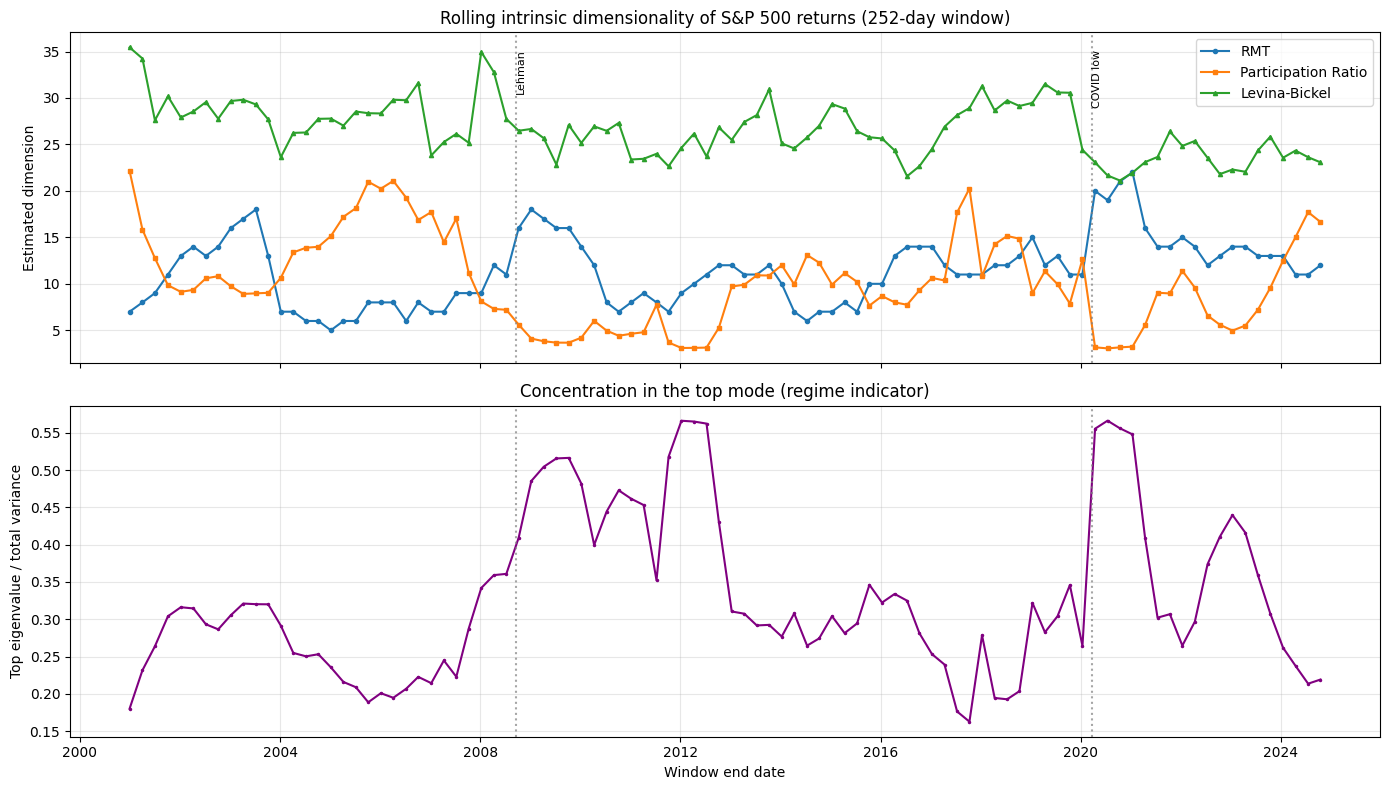

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(rolling.index, rolling["rmt"], label="RMT", marker="o", markersize=3)
axes[0].plot(rolling.index, rolling["pr"], label="Participation Ratio", marker="s", markersize=3)
axes[0].plot(rolling.index, rolling["lb"], label="Levina-Bickel", marker="^", markersize=3)
axes[0].set_ylabel("Estimated dimension")
axes[0].set_title("Rolling intrinsic dimensionality of S&P 500 returns (252-day window)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rolling.index, rolling["top_eig_share"], color="purple", marker=".", markersize=3)
axes[1].set_ylabel("Top eigenvalue / total variance")
axes[1].set_xlabel("Window end date")
axes[1].set_title("Concentration in the top mode (regime indicator)")
axes[1].grid(alpha=0.3)

for date_str, label in [("2008-09-15", "Lehman"), ("2020-03-23", "COVID low")]:
    d = pd.Timestamp(date_str)
    if rolling.index.min() <= d <= rolling.index.max():
        for ax in axes:
            ax.axvline(d, color="gray", linestyle=":", alpha=0.7)
        axes[0].text(d, axes[0].get_ylim()[1] * 0.95, label, rotation=90, va="top", fontsize=8)

plt.tight_layout()
plt.show()

# Evaluation - Random Asset Subsampling 

In [45]:
B_SUB = 100
SUB_FRAC = 0.80
rng_sub = np.random.default_rng(SEED)

p_sub = int(p * SUB_FRAC)
sub_results = {"rmt": [], "pr": [], "lb": []}

for _ in range(B_SUB):
    cols = rng_sub.choice(p, size=p_sub, replace=False)
    Xs = X[:, cols]
    cov_s = (Xs.T @ Xs) / (n - 1)
    es = eigh(cov_s, eigvals_only=True)[::-1]
    qs = p_sub / n

    # RMT (iterative σ²)
    s2_s = iter_sigma2(es, qs)
    edge_s = s2_s * (1 + np.sqrt(qs)) ** 2
    sub_results["rmt"].append(int((es > edge_s).sum()))

    # Participation ratio
    sub_results["pr"].append((es.sum() ** 2) / (es**2).sum())

    # Levina-Bickel
    nbrs_s = NearestNeighbors(n_neighbors=K + 1).fit(Xs)
    d_s, _ = nbrs_s.kneighbors(Xs)
    Tk_s = d_s[:, K]
    Tj_s = d_s[:, 1:K]
    lr_s = np.log((Tk_s[:, None] + 1e-12) / (Tj_s + 1e-12))
    ld_s = (K - 1) / lr_s.sum(axis=1)
    sub_results["lb"].append(ld_s[np.isfinite(ld_s)].mean())

stress = pd.DataFrame(
    {
        "estimator": ["RMT", "Participation Ratio", "Levina-Bickel"],
        "full_window": [rmt_dim, round(pr_dim, 2), round(lb_dim, 2)],
        "sub_mean": [np.mean(sub_results[k]) for k in ["rmt", "pr", "lb"]],
        "sub_std": [np.std(sub_results[k]) for k in ["rmt", "pr", "lb"]],
        "sub_cv_pct": [np.std(sub_results[k]) / np.mean(sub_results[k]) * 100 for k in ["rmt", "pr", "lb"]],
    }
)
print(f"80% asset subsampling, B={B_SUB} replicates")
print(stress.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

80% asset subsampling, B=100 replicates
          estimator  full_window  sub_mean  sub_std  sub_cv_pct
                RMT       149.00    114.92     3.19        2.77
Participation Ratio        10.24     10.17     0.29        2.80
      Levina-Bickel        29.48     28.75     0.62        2.15


# Evaluation - Moving-Block Bootstrap CI 

Moving-block bootstrap, B=200, block_len=20 days
          estimator  point  boot_mean  ci_2.5  ci_97.5  width
                RMT 149.00      60.65   44.00    77.03  33.03
Participation Ratio  10.24      10.33    7.17    14.62   7.45
      Levina-Bickel  29.48      15.07   10.08    20.99  10.91


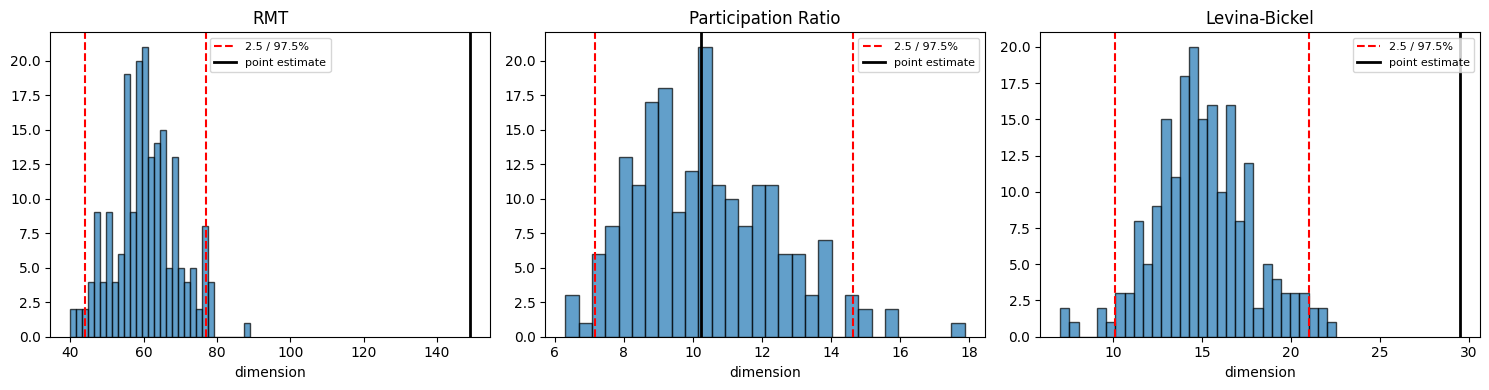

In [46]:
# Okay, the code wizards in this group love to torture me with their evil heiroglyphs of despair - Andy 
def estimators_from_X(Xb, K_=10):
    """
    Purpose: Takes returns matrix and converts it into all three dimensionality estimates
    
    Inputs: data matrix, # of nearest neighbors

    Outputs: # of eigenvalues above the Marchenko-Pastur upper edge, participation ratio, Levina-Bickel estimate
    """
    nb_, pb_ = Xb.shape
    Xb = Xb - Xb.mean(axis=0, keepdims=True)
    cov_b = (Xb.T @ Xb) / (nb_ - 1)
    eb = eigh(cov_b, eigvals_only=True)[::-1]
    qb = pb_ / nb_
    s2_b = iter_sigma2(eb, qb)
    edge_b = s2_b * (1 + np.sqrt(qb)) ** 2
    rmt_b = int((eb > edge_b).sum())
    pr_b = (eb.sum() ** 2) / (eb**2).sum()
    nbrs_b = NearestNeighbors(n_neighbors=K_ + 1).fit(Xb)
    db_, _ = nbrs_b.kneighbors(Xb)
    Tk_b, Tj_b = db_[:, K_], db_[:, 1:K_]
    lr_b = np.log((Tk_b[:, None] + 1e-12) / (Tj_b + 1e-12))
    ld_b = (K_ - 1) / lr_b.sum(axis=1)
    lb_b = ld_b[np.isfinite(ld_b)].mean()
    return rmt_b, pr_b, lb_b


B_BOOT = 200
BLOCK = 20  # approx. one trading month
rng_boot = np.random.default_rng(SEED)

n_blocks = int(np.ceil(n / BLOCK))
boot = {"rmt": [], "pr": [], "lb": []}
for _ in range(B_BOOT):
    starts = rng_boot.integers(0, n - BLOCK + 1, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + BLOCK) for s in starts])[:n]
    Xb = X_raw[idx]
    r_, p_, l_ = estimators_from_X(Xb, K_=K)
    boot["rmt"].append(r_)
    boot["pr"].append(p_)
    boot["lb"].append(l_)

ci_df = pd.DataFrame(
    {
        "estimator": ["RMT", "Participation Ratio", "Levina-Bickel"],
        "point": [rmt_dim, round(pr_dim, 2), round(lb_dim, 2)],
        "boot_mean": [np.mean(boot[k]) for k in ["rmt", "pr", "lb"]],
        "ci_2.5": [np.percentile(boot[k], 2.5) for k in ["rmt", "pr", "lb"]],
        "ci_97.5": [np.percentile(boot[k], 97.5) for k in ["rmt", "pr", "lb"]],
        "width": [np.percentile(boot[k], 97.5) - np.percentile(boot[k], 2.5) for k in ["rmt", "pr", "lb"]],
    }
)
print(f"Moving-block bootstrap, B={B_BOOT}, block_len={BLOCK} days")
print(ci_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
points = {"rmt": rmt_dim, "pr": pr_dim, "lb": lb_dim}
names = {"rmt": "RMT", "pr": "Participation Ratio", "lb": "Levina-Bickel"}
for ax, key in zip(axes, ["rmt", "pr", "lb"]):
    ax.hist(boot[key], bins=30, alpha=0.7, edgecolor="k")
    ax.axvline(np.percentile(boot[key], 2.5), color="red", linestyle="--", label="2.5 / 97.5%")
    ax.axvline(np.percentile(boot[key], 97.5), color="red", linestyle="--")
    ax.axvline(points[key], color="black", linewidth=2, label="point estimate")
    ax.set_title(names[key])
    ax.set_xlabel("dimension")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Formalizing Methodologies

In [47]:
# rmt_dim_from_evals is a slight change-up from rmt_count, but it does effectively the same thing! We had some hiccups with later functions, and 
# for convencience sake, we decided to just define a second function instead of reconciling all of the later functions.

# Also, this is just functionalizing the methods that have already been explained, so I won't leave specific commentary on the purpose + I/O of them.

def rmt_dim_from_evals(evs, q_):
    s2 = iter_sigma2(evs, q_)
    edge = s2 * (1 + np.sqrt(q_)) ** 2
    return int((evs > edge).sum()), s2, edge

def participation_ratio(evs):
    return float((evs.sum() ** 2) / (evs**2).sum())

def levina_bickel(X_, k=10):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_)
    d, _ = nbrs.kneighbors(X_)
    Tk = d[:, k]
    Tj = d[:, 1:k]
    lr = np.log((Tk[:, None] + 1e-12) / (Tj + 1e-12))
    ld = (k - 1) / lr.sum(axis=1)
    return float(ld[np.isfinite(ld)].mean())


rmt_dim, sigma2, mp_upper = rmt_dim_from_evals(evals, q)
pr_dim = participation_ratio(evals)
lb_dim = levina_bickel(X, k=10)

print(f"RMT (iterative σ²):   {rmt_dim}    (σ²={sigma2:.4e}, λ+={mp_upper:.4e})")
print(f"Participation Ratio:  {pr_dim:.2f}")
print(f"Levina-Bickel (k=10): {lb_dim:.2f}")

RMT (iterative σ²):   149    (σ²=4.1321e-05, λ+=1.6298e-04)
Participation Ratio:  10.24
Levina-Bickel (k=10): 29.48


# RMT - Covariance Matrix (Cleaned Covariance)

Signal eigs kept:                  149 of 489
Noise eigs replaced with mean:     4.1321e-05
Trace (raw):                       1.529194e-01
Trace (cleaned):                   1.529194e-01    (preserved by construction)
Condition number (raw):            4.93e+06
Condition number (cleaned):        1.12e+03    (~4418× better)


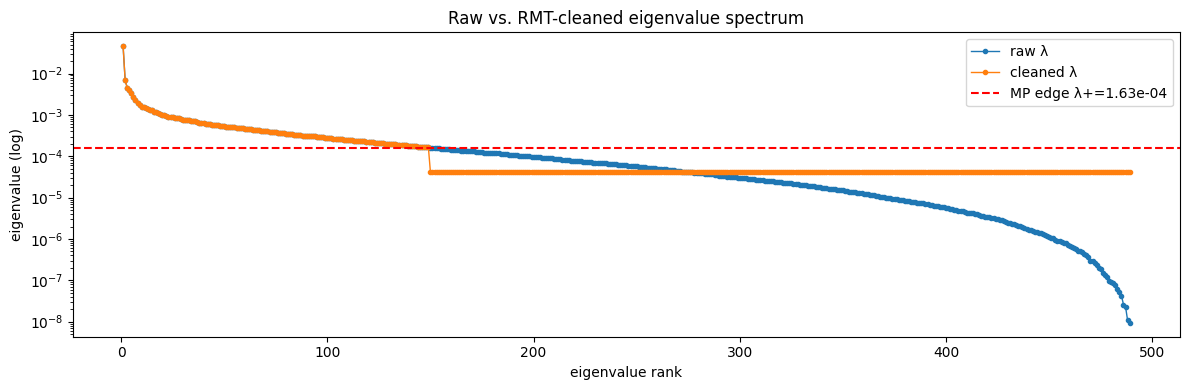

In [48]:
def rmt_clean_covariance(evals_, evecs_, mp_upper_):
    """
    Purpose: Replace noise eigenvalues with their mean, reconstruct symmetric PSD cov. Makes a "clean" or "denoised" covariance matrix for asset returns :)

    Uses only positive noise eigenvalues to estimate the noise mean, and handles the
    q > 1 case where some noise eigenvalues are numerically zero/negative due to
    rank deficiency. The fill value floors all noise eigenvalues at a strictly
    positive number, guaranteeing the reconstructed cov is positive definite.
    
    Inputs: eigenvalues, eigenvectors, the MP upper edge

    Outputs: cleaned cov matrix, denoised eigenvalues
    """

    e = evals_.copy()
    signal_mask = e > mp_upper_
    noise_mask = ~signal_mask
    if noise_mask.sum() > 0:
        positive_noise = e[noise_mask & (e > 0)]
        if len(positive_noise) > 0:
            noise_mean = positive_noise.mean()
        elif signal_mask.sum() > 0:
            noise_mean = e[signal_mask].min()
        else:
            noise_mean = max(mp_upper_, 1e-15)
        e[noise_mask] = noise_mean # Tentative research tells me that this is a financial adaptation of Rotationally Invariant Estimators (RIEs). Neat!
    cleaned = evecs_ @ np.diag(e) @ evecs_.T
    cleaned = (cleaned + cleaned.T) / 2.0
    return cleaned, e


cov_cleaned, evals_cleaned = rmt_clean_covariance(evals, evecs, mp_upper)

cond_raw = evals[0] / evals[-1] if evals[-1] > 0 else np.inf
cond_cleaned = evals_cleaned.max() / evals_cleaned.min()
trace_raw = evals.sum()
trace_cleaned = evals_cleaned.sum()

print(f"Signal eigs kept:                  {(evals > mp_upper).sum()} of {p}")
print(f"Noise eigs replaced with mean:     {evals[(evals <= mp_upper) & (evals > 0)].mean():.4e}")
print(f"Trace (raw):                       {trace_raw:.6e}")
print(f"Trace (cleaned):                   {trace_cleaned:.6e}    (preserved by construction)")
print(f"Condition number (raw):            {cond_raw:.2e}")
print(f"Condition number (cleaned):        {cond_cleaned:.2e}    (~{cond_raw / cond_cleaned:.0f}× better)")

fig, ax = plt.subplots(figsize=(12, 4))
rank = np.arange(1, p + 1)
ax.plot(rank, evals, label="raw λ", marker=".", linewidth=1)
ax.plot(rank, evals_cleaned, label="cleaned λ", marker=".", linewidth=1)
ax.axhline(mp_upper, color="red", linestyle="--", label=f"MP edge λ+={mp_upper:.2e}")
ax.set_yscale("log")
ax.set_xlabel("eigenvalue rank")
ax.set_ylabel("eigenvalue (log)")
ax.set_title("Raw vs. RMT-cleaned eigenvalue spectrum")
ax.legend()
plt.tight_layout()
plt.show()

# Global Minimum-Variance Portfolios (Full vs. Cleaned Covariance Matrices)

In [49]:
def gmv_weights(cov_):
    """
    Purpose: Get the asset weights needed to build the GMV portfolio
    
    Inputs: covariance matrix

    Outputs: portfolio weights of the Global Minimum-Variance Portfolio (collection of assets that produces the last returns variance on the efficient frontier)
    """
    ones = np.ones(cov_.shape[0])
    inv_cov_ones = np.linalg.solve(cov_, ones)
    return inv_cov_ones / (ones @ inv_cov_ones)


w_raw = gmv_weights(cov)
w_cleaned = gmv_weights(cov_cleaned)


def portfolio_metrics(w, label, cov_self, cov_other, other_label):
    """
    Purpose: Computes a set of diagnostic statistics for a given portfolio weight vector under two different covariance matricies
    
    Inputs: weights, portfolio name (label), cov matrix to make the weights, other cov matrix, other portfolio name (label)

    Outputs: portfolio weights of the Global Minimum-Variance Portfolio (collection of assets that produces the last returns variance on the efficient frontier)
    """
    return {
        "portfolio": label,
        f"variance under {label} cov": float(w @ cov_self @ w),
        f"variance under {other_label} cov": float(w @ cov_other @ w),
        "gross leverage Σ|w|": float(np.abs(w).sum()),
        "max |w|": float(np.abs(w).max()),
        "effective # names 1/Σw²": float(1.0 / (w**2).sum()),
        "# negative weights": int((w < 0).sum()),
    }


m_raw = portfolio_metrics(w_raw, "raw", cov, cov_cleaned, "cleaned")
m_cleaned = portfolio_metrics(w_cleaned, "cleaned", cov_cleaned, cov, "raw")

# Pretty-print side by side
keys = list(m_raw.keys())
for k in keys:
    if k == "portfolio":
        print(f"{'metric':<32} {'GMV(raw)':>16} {'GMV(cleaned)':>16}")
        print("-" * 66)
        continue
    # The cross-cov keys differ between m_raw / m_cleaned; align by ordinal
    pass


# Build a parallel printout
def fmt(v):
    if isinstance(v, float):
        return f"{v:.4e}" if abs(v) < 0.01 or abs(v) > 1e3 else f"{v:.4f}"
    return str(v)


labels_and_keys = [
    ("ex-ante variance (own cov)", "variance under raw cov", "variance under cleaned cov"),
    ("ex-ante variance (other cov)", "variance under cleaned cov", "variance under raw cov"),
    ("gross leverage Σ|w|", "gross leverage Σ|w|", "gross leverage Σ|w|"),
    ("max |w|", "max |w|", "max |w|"),
    ("effective # names", "effective # names 1/Σw²", "effective # names 1/Σw²"),
    ("# negative weights", "# negative weights", "# negative weights"),
]
print(f"{'metric':<32} {'GMV(raw)':>16} {'GMV(cleaned)':>16}")
print("-" * 66)
for label, k_r, k_c in labels_and_keys:
    print(f"{label:<32} {fmt(m_raw[k_r]):>16} {fmt(m_cleaned[k_c]):>16}")

print()
print("Interpretation:")
print(f"  - GMV(raw) in-sample variance is lower than GMV(cleaned) in-sample by construction,")
print(f"    but that's the variance of an over-fit portfolio. The cross-cov columns are the")
print(f"    informative, 'out-of-sample' values: GMV(cleaned) evaluated under Σ_raw is the honest representation of the cleaned portfolio's superiority.")
print(f"  - Gross leverage drops by {m_raw['gross leverage Σ|w|'] / m_cleaned['gross leverage Σ|w|']:.1f}x after cleaning")
print(f"  - the raw inverse cov matrix blows up small eigs, producing extreme long-short weights.")

metric                                   GMV(raw)     GMV(cleaned)
------------------------------------------------------------------
metric                                   GMV(raw)     GMV(cleaned)
------------------------------------------------------------------
ex-ante variance (own cov)             3.8243e-07       7.9909e-06
ex-ante variance (other cov)           7.5382e-04       9.1018e-06
gross leverage Σ|w|                       68.2954           6.4780
max |w|                                    0.8459           0.0645
effective # names                          0.0548           7.2481
# negative weights                            237              222

Interpretation:
  - GMV(raw) in-sample variance is lower than GMV(cleaned) in-sample by construction,
    but that's the variance of an over-fit portfolio. The cross-cov columns are the
    informative, 'out-of-sample' values: GMV(cleaned) evaluated under Σ_raw is the honest representation of the cleaned portfolio's superiority

# PC1 - PC5 Eigenportfolios (Ported from John's OOP File)

In [50]:
def eigenportfolio(evec, normalize="l1"):
    """
    Purpose: Turn eigenvector into portfolio weight vector by normalizing it
    
    Inputs: eigenvector, normalization method

    Outputs: normalize eigenvector (portfolio weight)
    """
    v = evec.copy()
    if normalize == "l1":
        denom = np.abs(v).sum()
    elif normalize == "l2":
        denom = np.linalg.norm(v)
    elif normalize == "sum1":
        denom = v.sum()
    elif normalize is None:
        denom = 1.0
    else:
        raise ValueError(normalize)
    return v / denom if denom != 0 else v


N_PCS = 5
eigenport_weights = np.column_stack([eigenportfolio(evecs[:, i], "l1") for i in range(N_PCS)])
eigenport_df = pd.DataFrame(
    eigenport_weights,
    index=returns_win.columns,
    columns=[f"PC{i+1}" for i in range(N_PCS)],
)
eigenport_df["company"] = [col_to_company.get(c, "?") for c in eigenport_df.index]

# Show top-5 long and top-5 short per component
print("Top 5 long and top 5 short positions per eigenportfolio:\n")
for i in range(N_PCS):
    pc = f"PC{i+1}"
    series = eigenport_df[pc]
    top_long = series.nlargest(5)
    top_short = series.nsmallest(5)
    print(f"=== {pc}  (variance share = {evals[i] / evals.sum():.1%}, sign of net weight: {'+' if series.sum() > 0 else '-'}) ===")
    print("  LONG:")
    for tic, w in top_long.items():
        print(f"    {tic:<12} {w:+.4f}   {col_to_company.get(tic, '?')}")
    print("  SHORT:")
    for tic, w in top_short.items():
        print(f"    {tic:<12} {w:+.4f}   {col_to_company.get(tic, '?')}")
    print()

Top 5 long and top 5 short positions per eigenportfolio:

=== PC1  (variance share = 30.1%, sign of net weight: -) ===
  LONG:
    AEP          -0.0000   AMERICAN ELECTRIC POWER CO INC
    WEC          -0.0001   W E C ENERGY GROUP INC
    CMS          -0.0001   C M S ENERGY CORP
    XEL          -0.0001   X C E L ENERGY INC
    DUK          -0.0001   DUKE ENERGY CORP NEW
  SHORT:
    AMD          -0.0047   ADVANCED MICRO DEVICES INC
    NVDA         -0.0045   NVIDIA CORP
    URI          -0.0044   UNITED RENTALS INC
    MU           -0.0044   MICRON TECHNOLOGY INC
    IPGP         -0.0040   I P G PHOTONICS CORP

=== PC2  (variance share = 4.5%, sign of net weight: +) ===
  LONG:
    WELL         +0.0056   WELLTOWER INC
    VTR          +0.0055   VENTAS INC
    AMT          +0.0050   AMERICAN TOWER CORP NEW
    O            +0.0049   REALTY INCOME CORP
    SBAC         +0.0049   S B A COMMUNICATIONS CORP NEW
  SHORT:
    APA          -0.0068   A P A CORP
    XEC          -0.0065   CIMAR

# Cumulative Returns from Eigenportfolios

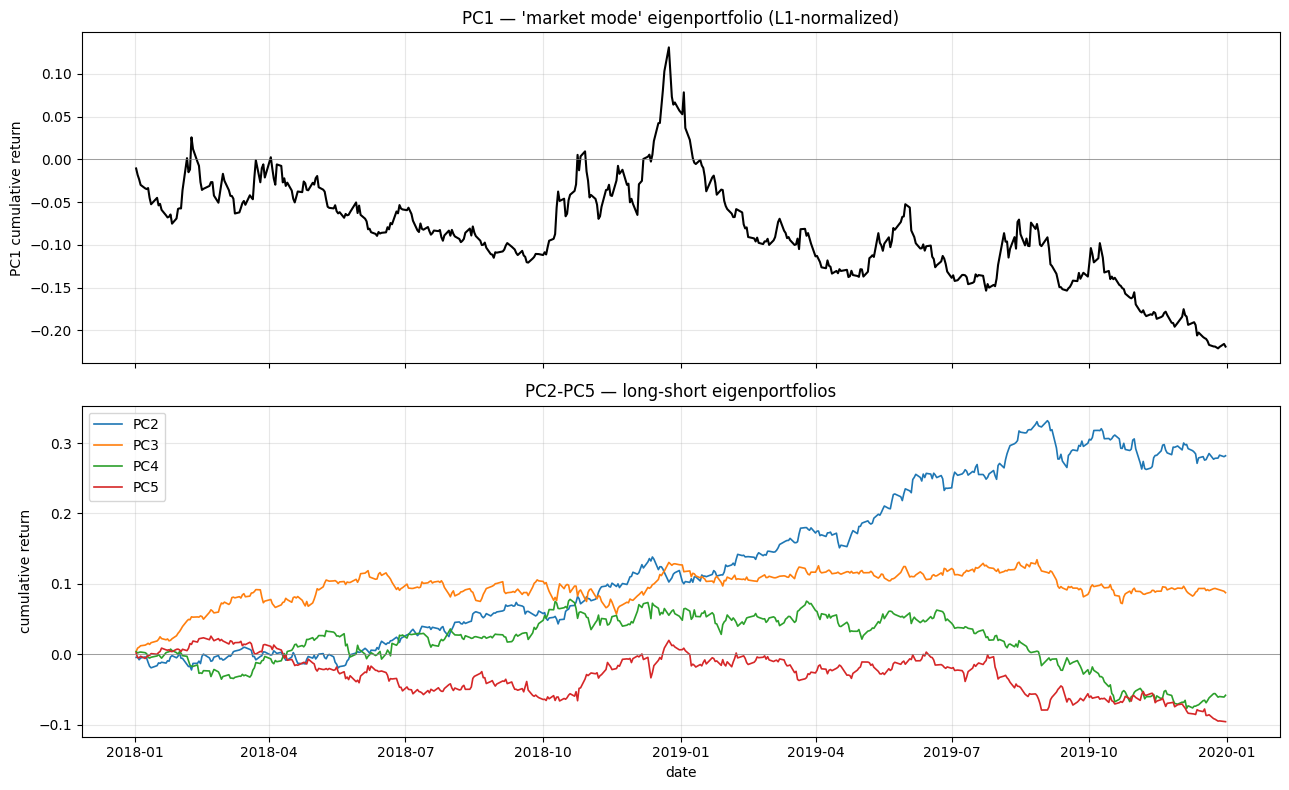


Annualized stats per eigenportfolio (window = 2018-2019):

     ann_return  ann_vol  sharpe  var_share
PC1     -0.1098   0.1672 -0.6565     0.3014
PC2      0.1271   0.0726  1.7498     0.0446
PC3      0.0439   0.0616  0.7126     0.0299
PC4     -0.0267   0.0822 -0.3251     0.0255
PC5     -0.0474   0.0777 -0.6108     0.0226


In [51]:
# Apply L1-normalized weights to returns. eigenport_weights is (p, N_PCS).
daily_returns = X_raw @ eigenport_weights  # (n,p) @ (n, N_PCS) = (n, N_PCS)
cum_returns = np.cumprod(1 + daily_returns, axis=0) - 1
cum_df = pd.DataFrame(cum_returns, index=returns_win.index, columns=[f"PC{i+1}" for i in range(N_PCS)])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# PC1 alone — has very different scale than the long-short factors
axes[0].plot(cum_df.index, cum_df["PC1"], color="black", linewidth=1.5)
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].set_ylabel("PC1 cumulative return")
axes[0].set_title("PC1 — 'market mode' eigenportfolio (L1-normalized)")
axes[0].grid(alpha=0.3)

# PC2-PC5 together
for col in ["PC2", "PC3", "PC4", "PC5"]:
    axes[1].plot(cum_df.index, cum_df[col], label=col, linewidth=1.2)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].set_ylabel("cumulative return")
axes[1].set_xlabel("date")
axes[1].set_title("PC2-PC5 — long-short eigenportfolios")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
ann_factor = 252
print("\nAnnualized stats per eigenportfolio (window = 2018-2019):\n")
stats = pd.DataFrame(
    {
        "ann_return": daily_returns.mean(axis=0) * ann_factor,
        "ann_vol": daily_returns.std(axis=0) * np.sqrt(ann_factor),
        "sharpe": (daily_returns.mean(axis=0) / daily_returns.std(axis=0)) * np.sqrt(ann_factor),
        "var_share": [evals[i] / evals.sum() for i in range(N_PCS)],
    },
    index=[f"PC{i+1}" for i in range(N_PCS)],
)
print(stats.to_string(float_format=lambda x: f"{x:.4f}"))

# Rolling Assessment of GMV Portfolios

In [52]:
WIN_DAYS = 504  # ~2 trading years — keeps q = p/n < 1 so MP and matrix inversion are well-posed (we learned this the hard way when tracking dimensionality throughout time)
STEP_DAYS = 63
records_v2 = []
dates = returns_full.index

for start_idx in range(0, len(dates) - WIN_DAYS + 1, STEP_DAYS):
    end_idx = start_idx + WIN_DAYS
    end_date = dates[end_idx - 1]
    members_w = members_as_of(end_date)
    cols_w = members_to_columns(members_w)
    win = returns_full.iloc[start_idx:end_idx][cols_w].dropna(axis=1, how="any")
    n_w, p_w = win.shape
    if p_w < 20 or p_w >= n_w:
        continue

    Xw = win.to_numpy(dtype=float)
    Xw = Xw - Xw.mean(axis=0, keepdims=True)
    cov_w = (Xw.T @ Xw) / (n_w - 1)
    ev_w, vec_w = eigh(cov_w)
    ev_w = ev_w[::-1]
    vec_w = vec_w[:, ::-1]
    q_w = p_w / n_w

    s2_w = iter_sigma2(ev_w, q_w)
    edge_w = s2_w * (1 + np.sqrt(q_w)) ** 2
    cov_clean_w, ev_clean_w = rmt_clean_covariance(ev_w, vec_w, edge_w)

    try:
        w_r = gmv_weights(cov_w)
        w_c = gmv_weights(cov_clean_w)
        gross_r = float(np.abs(w_r).sum())
        gross_c = float(np.abs(w_c).sum())
    except np.linalg.LinAlgError:
        gross_r = gross_c = np.nan

    pos_raw = ev_w[ev_w > 0]
    cond_raw_w = float(pos_raw.max() / pos_raw.min()) if len(pos_raw) > 0 else np.nan
    cond_cleaned_w = float(ev_clean_w.max() / ev_clean_w.min())

    records_v2.append(
        {
            "window_end": end_date,
            "n_assets": p_w,
            "q": q_w,
            "rmt_dim": int((ev_w > edge_w).sum()),
            "top_eig_share": ev_w[0] / ev_w.sum(),
            "cond_raw": cond_raw_w,
            "cond_cleaned": cond_cleaned_w,
            "gross_raw": gross_r,
            "gross_cleaned": gross_c,
        }
    )

rolling_v2 = pd.DataFrame(records_v2).set_index("window_end")
rolling_v2["cond_ratio"] = rolling_v2["cond_raw"] / rolling_v2["cond_cleaned"]
rolling_v2["gross_ratio"] = rolling_v2["gross_raw"] / rolling_v2["gross_cleaned"]
print(f"Computed {len(rolling_v2)} rolling windows ({WIN_DAYS}-day window).")
print(f"q range across windows: [{rolling_v2['q'].min():.3f}, {rolling_v2['q'].max():.3f}]")
rolling_v2[["n_assets", "q", "rmt_dim", "top_eig_share", "cond_ratio", "gross_ratio"]].head()

Computed 86 rolling windows (504-day window).
q range across windows: [0.935, 0.996]


,n_assets,q,rmt_dim,top_eig_share,cond_ratio,gross_ratio
window_end,,,,,,
2002-01-07,472,0.9365,139,0.2453,620.6438,5.3872
2002-04-09,474,0.9405,155,0.2663,664.0463,5.8157
2002-07-09,478,0.9484,154,0.2722,649.0970,5.2271
2002-10-07,478,0.9484,162,0.2840,605.1685,5.1074
2003-01-07,481,0.9544,162,0.2963,1393.5763,5.5442


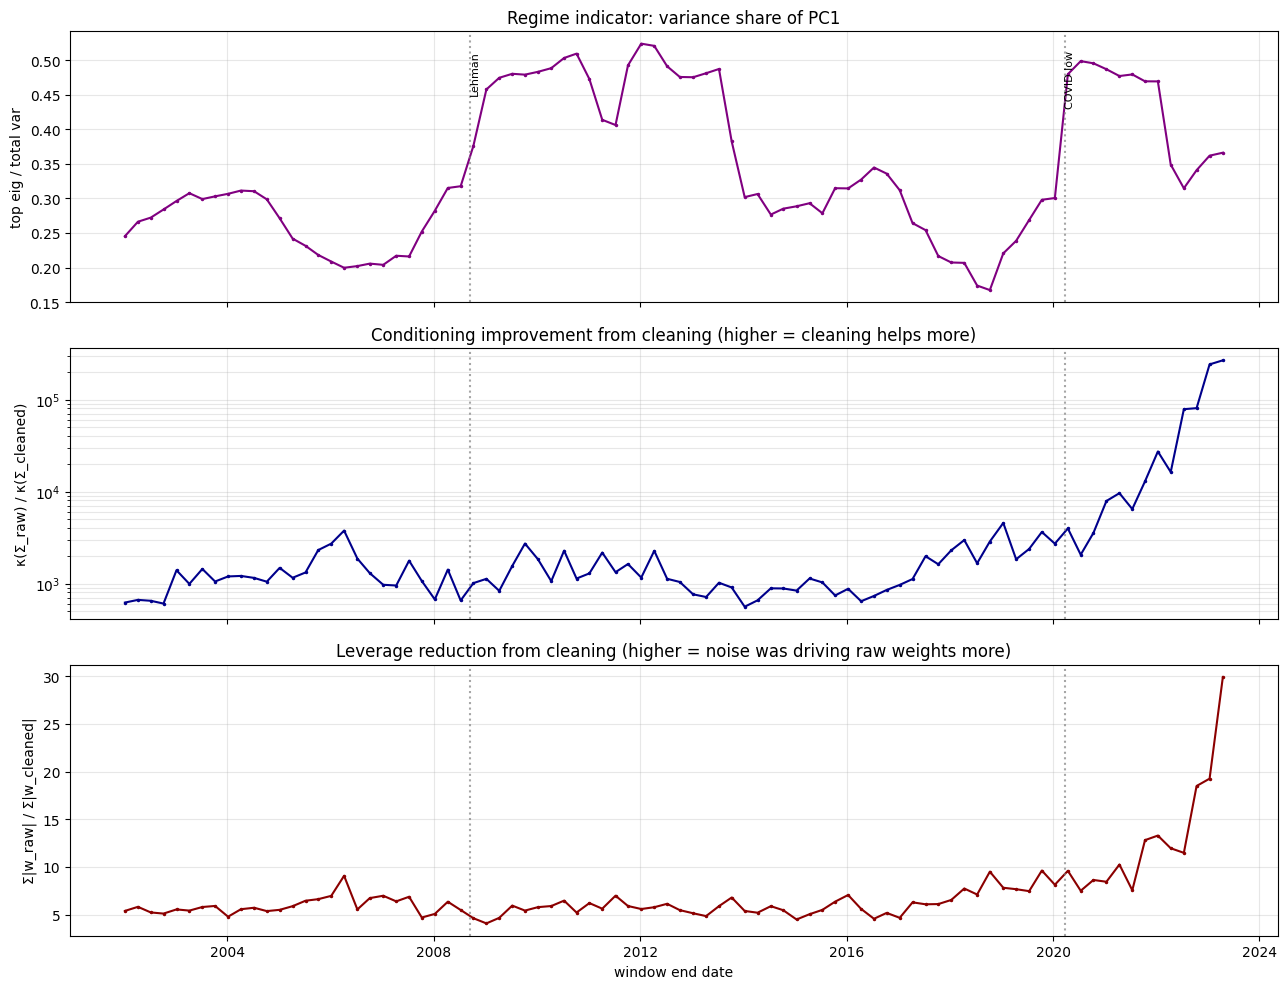

In [53]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(rolling_v2.index, rolling_v2["top_eig_share"], color="purple", marker=".", markersize=3)
axes[0].set_ylabel("top eig / total var")
axes[0].set_title("Regime indicator: variance share of PC1")
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_v2.index, rolling_v2["cond_ratio"], color="darkblue", marker=".", markersize=3)
axes[1].set_yscale("log")
axes[1].set_ylabel("κ(Σ_raw) / κ(Σ_cleaned)")
axes[1].set_title("Conditioning improvement from cleaning (higher = cleaning helps more)")
axes[1].grid(alpha=0.3, which="both")

axes[2].plot(rolling_v2.index, rolling_v2["gross_ratio"], color="darkred", marker=".", markersize=3)
axes[2].set_ylabel("Σ|w_raw| / Σ|w_cleaned|")
axes[2].set_xlabel("window end date")
axes[2].set_title("Leverage reduction from cleaning (higher = noise was driving raw weights more)")
axes[2].grid(alpha=0.3)

for date_str, label in [("2008-09-15", "Lehman"), ("2020-03-23", "COVID low")]:
    d = pd.Timestamp(date_str)
    if rolling_v2.index.min() <= d <= rolling_v2.index.max():
        for ax in axes:
            ax.axvline(d, color="gray", linestyle=":", alpha=0.7)
        axes[0].text(d, axes[0].get_ylim()[1] * 0.95, label, rotation=90, va="top", fontsize=8)

plt.tight_layout()
plt.show()